M.Talha Ramzan
---

23330-0141
----

BS AI
----

**TAsk no 01**

In [1]:
# Cell 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
# Cell 2: Load Dataset
df = pd.read_csv('heart.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Cell 3: Basic EDA
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['target'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        

In [4]:
# Cell 4: Feature/Target Split
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:", list(X.columns))

Features shape: (1025, 13)
Target shape: (1025,)

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [5]:
# Cell 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (820, 13)
Test size:  (205, 13)


In [6]:
# Cell 6: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done!")
print("Sample scaled row:", X_train[0])

Scaling done!
Sample scaled row: [-0.58584022  0.65465367  1.008275   -0.77945357 -1.93503098 -0.41403934
 -0.9837419  -1.01909426 -0.72594894 -0.21066121  1.00526437  2.17169136
 -0.54519316]


In [7]:
# Cell 7: ANN - 1 Hidden Layer, 8 Neurons
model_1 = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden Layer
    Dense(1, activation='sigmoid')                                   # Output Layer
])

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Cell 8: Train Model 1
history_1 = model_1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5488 - loss: 0.7152 - val_accuracy: 0.5488 - val_loss: 0.7480
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6052 - loss: 0.6662 - val_accuracy: 0.5854 - val_loss: 0.7114
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6448 - loss: 0.6252 - val_accuracy: 0.6463 - val_loss: 0.6775
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6829 - loss: 0.5872 - val_accuracy: 0.6524 - val_loss: 0.6487
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7317 - loss: 0.5536 - val_accuracy: 0.6829 - val_loss: 0.6236
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7409 - loss: 0.5242 - val_accuracy: 0.6951 - val_loss: 0.6004
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7530 - loss: 0.4984 - val_accuracy: 0.7134 - val_loss: 0.5801
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7851 - loss: 0.4754 - val_accuracy: 0.7256 - val_loss

In [9]:
# Cell 9: Evaluate Model 1
loss_1, acc_1 = model_1.evaluate(X_test, y_test, verbose=0)
print(f"Model 1 (1 Hidden Layer, 8 Neurons)")
print(f"  Test Accuracy : {acc_1*100:.2f}%")
print(f"  Test Loss     : {loss_1:.4f}")

Model 1 (1 Hidden Layer, 8 Neurons)
  Test Accuracy : 80.98%
  Test Loss     : 0.4307


In [10]:
# Cell 10: ANN - 1 Hidden Layer, 16 Neurons
model_2 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_2 = model_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_2, acc_2 = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 (1 Hidden Layer, 16 Neurons) → Accuracy: {acc_2*100:.2f}%")

Model 2 (1 Hidden Layer, 16 Neurons) → Accuracy: 83.41%


In [11]:
# Cell 11: ANN - 2 Hidden Layers (16 → 8)
model_3 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden Layer 1
    Dense(8,  activation='relu'),                                    # Hidden Layer 2
    Dense(1,  activation='sigmoid')                                  # Output Layer
])

model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_3 = model_3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_3, acc_3 = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Model 3 (2 Hidden Layers: 16→8) → Accuracy: {acc_3*100:.2f}%")

Model 3 (2 Hidden Layers: 16→8) → Accuracy: 85.85%


In [12]:
# Cell 12: Experiment with 32 and 64 neurons (2 hidden layers)
results = {}

for neurons in [8, 16, 32, 64]:
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(neurons // 2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_split=0.2, verbose=0)
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    results[f'{neurons} neurons'] = round(acc * 100, 2)
    print(f"  Neurons: {neurons} → Accuracy: {acc*100:.2f}%")

print("\nSummary:", results)

  Neurons: 8 → Accuracy: 80.49%
  Neurons: 16 → Accuracy: 86.83%
  Neurons: 32 → Accuracy: 92.20%
  Neurons: 64 → Accuracy: 94.63%

Summary: {'8 neurons': 80.49, '16 neurons': 86.83, '32 neurons': 92.2, '64 neurons': 94.63}


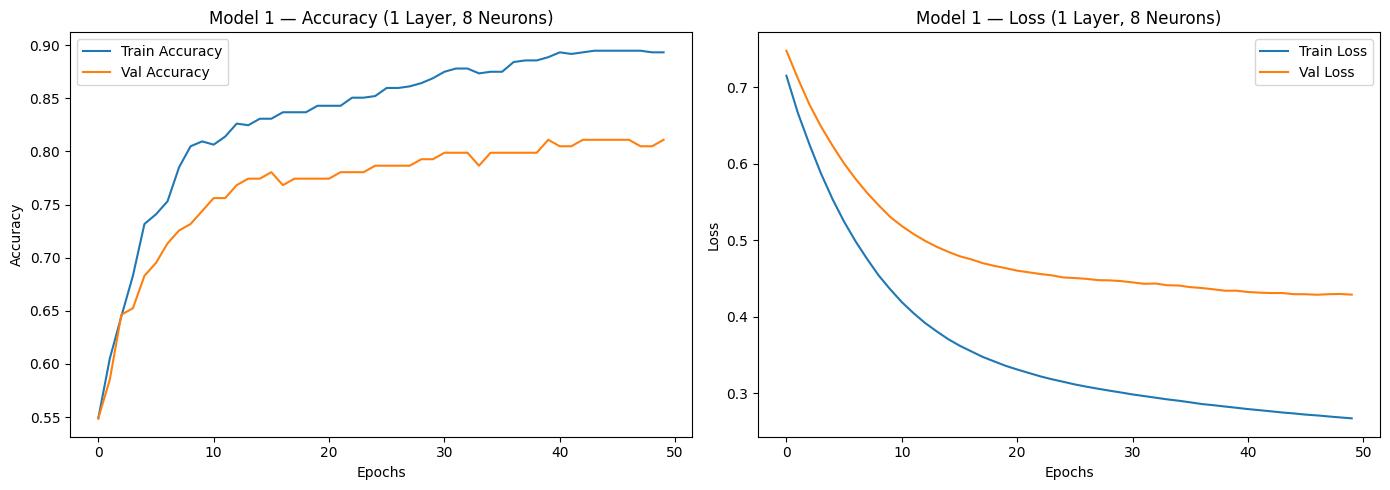

In [13]:
# Cell 13: Plot Accuracy & Loss Curves for Model 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_1.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_1.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model 1 — Accuracy (1 Layer, 8 Neurons)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_1.history['loss'],     label='Train Loss')
axes[1].plot(history_1.history['val_loss'], label='Val Loss')
axes[1].set_title('Model 1 — Loss (1 Layer, 8 Neurons)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

**`Task 2 — Learning Rate & Epochs Experiment`**

In [18]:
# Cell 18: Helper function to build model (FIXED)
from tensorflow.keras.optimizers import Adam   # ← yeh line add ki

def build_model(learning_rate):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(8,  activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_model() function ready!")

build_model() function ready!


In [19]:
# Cell 19: Train all 4 combinations (FIXED)
from tensorflow.keras.optimizers import Adam

configs = [
    {'lr': 0.001, 'epochs': 50},
    {'lr': 0.001, 'epochs': 100},
    {'lr': 0.01,  'epochs': 50},
    {'lr': 0.01,  'epochs': 100},
]

histories = {}
test_results = {}

for cfg in configs:
    key = f"LR={cfg['lr']}, Epochs={cfg['epochs']}"
    print(f"\n🔄 Training: {key}")

    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(8,  activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=cfg['lr']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, y_train,
        epochs=cfg['epochs'],
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    histories[key]    = history
    test_results[key] = round(acc * 100, 2)
    print(f"   ✅ Test Accuracy: {acc*100:.2f}%")

print("\n✅ All models trained!")


🔄 Training: LR=0.001, Epochs=50
   ✅ Test Accuracy: 81.95%

🔄 Training: LR=0.001, Epochs=100
   ✅ Test Accuracy: 87.80%

🔄 Training: LR=0.01, Epochs=50
   ✅ Test Accuracy: 94.63%

🔄 Training: LR=0.01, Epochs=100
   ✅ Test Accuracy: 95.12%

✅ All models trained!


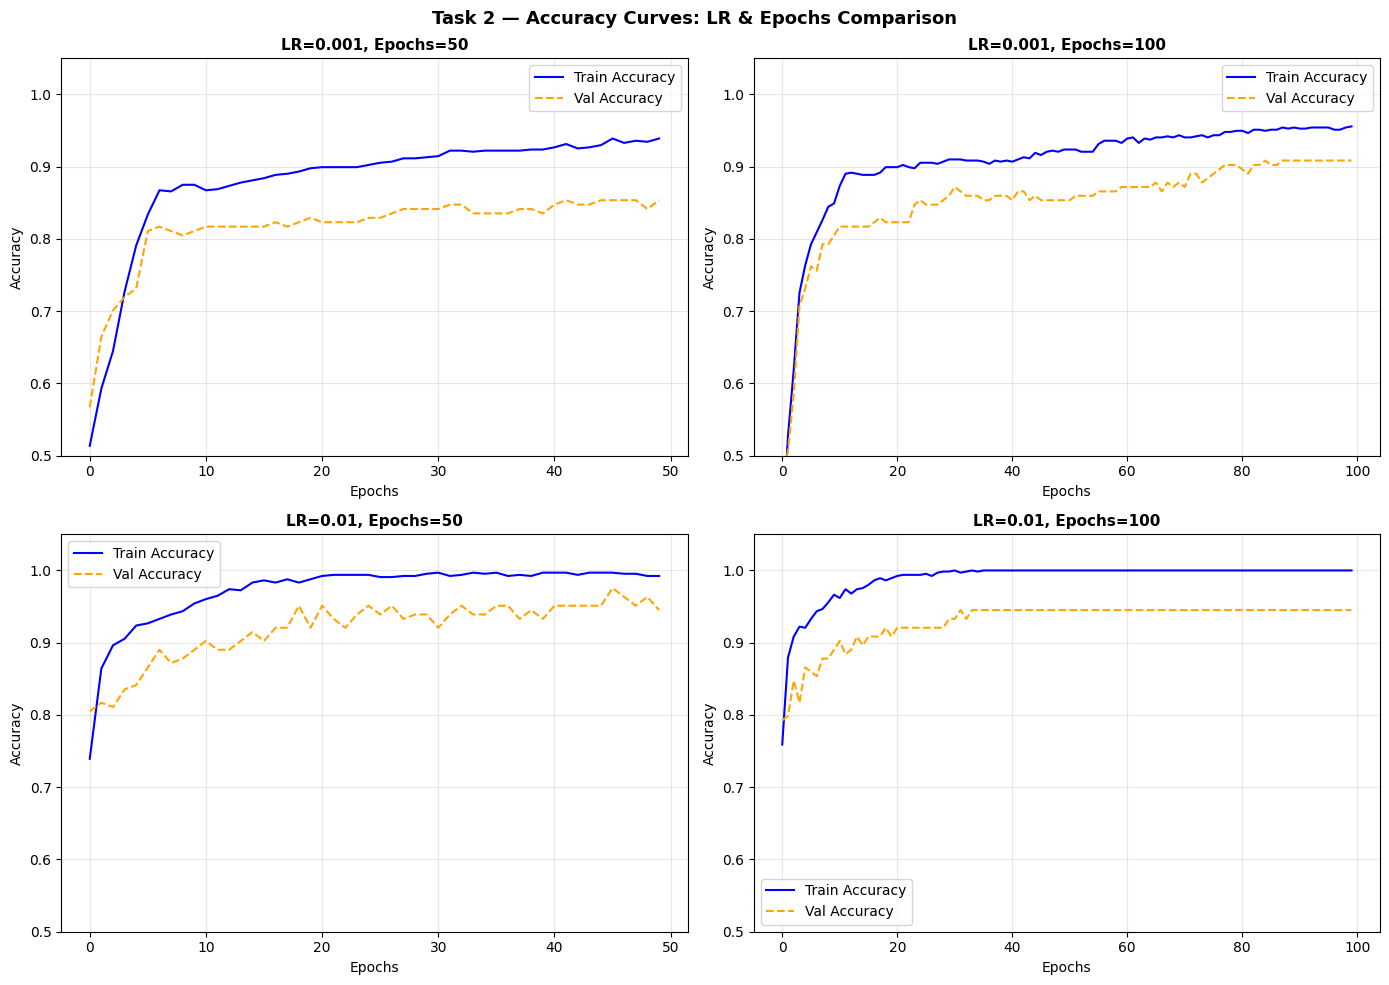

In [20]:
# Cell 20: Accuracy curves for all 4 combinations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (key, history) in enumerate(histories.items()):
    axes[i].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    axes[i].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
    axes[i].set_title(key, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].set_ylim(0.5, 1.05)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Task 2 — Accuracy Curves: LR & Epochs Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

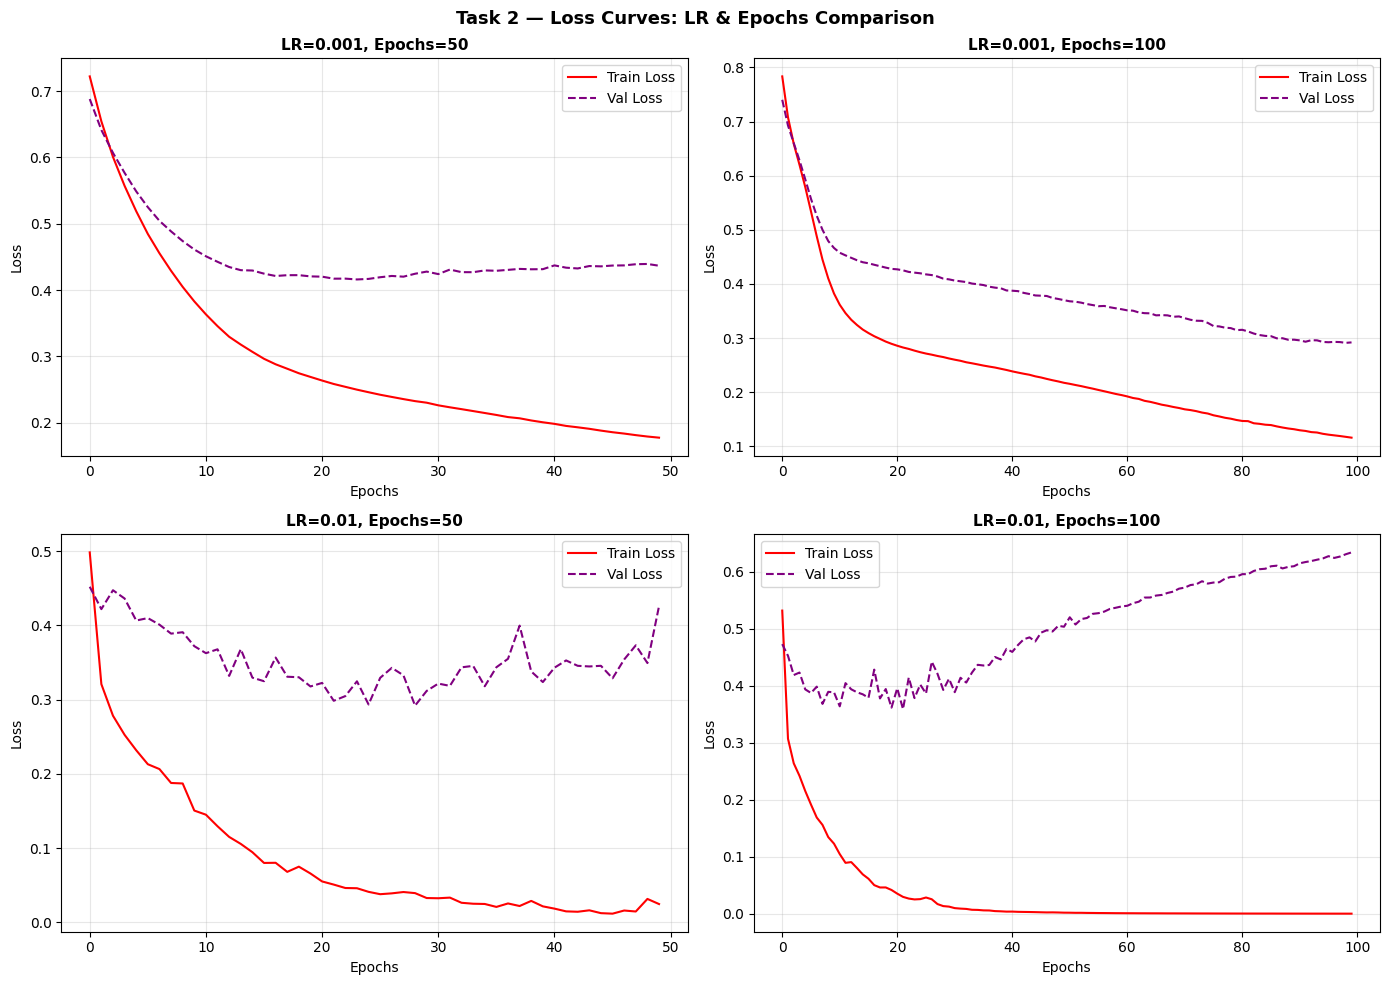

In [21]:
# Cell 21: Loss curves for all 4 combinations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (key, history) in enumerate(histories.items()):
    axes[i].plot(history.history['loss'],     label='Train Loss', color='red')
    axes[i].plot(history.history['val_loss'], label='Val Loss',   color='purple', linestyle='--')
    axes[i].set_title(key, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Task 2 — Loss Curves: LR & Epochs Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

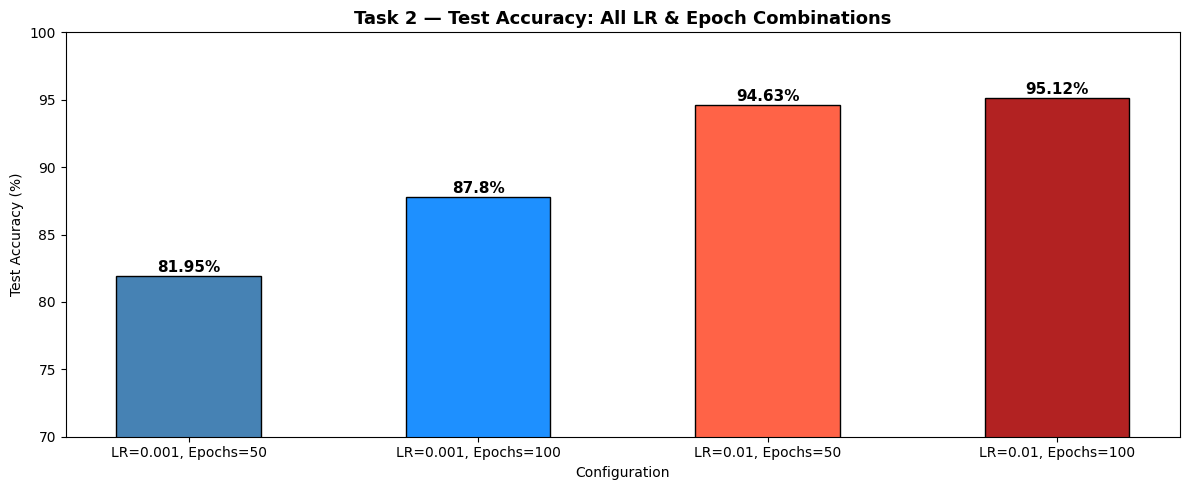

In [22]:
# Cell 22: Bar chart - final accuracy comparison
labels = list(test_results.keys())
values = list(test_results.values())
colors = ['steelblue', 'dodgerblue', 'tomato', 'firebrick']

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.5)
plt.ylim(70, 100)
plt.title('Task 2 — Test Accuracy: All LR & Epoch Combinations', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.xlabel('Configuration')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Cell 23: Summary comparison table
summary_t2 = pd.DataFrame({
    'Configuration':     list(test_results.keys()),
    'Learning Rate':     [0.001, 0.001, 0.01, 0.01],
    'Epochs':            [50, 100, 50, 100],
    'Test Accuracy (%)': list(test_results.values())
})

print("=" * 65)
print("         TASK 2 — FINAL RESULTS SUMMARY")
print("=" * 65)
print(summary_t2.to_string(index=False))
print("=" * 65)

         TASK 2 — FINAL RESULTS SUMMARY
       Configuration  Learning Rate  Epochs  Test Accuracy (%)
 LR=0.001, Epochs=50          0.001      50              81.95
LR=0.001, Epochs=100          0.001     100              87.80
  LR=0.01, Epochs=50          0.010      50              94.63
 LR=0.01, Epochs=100          0.010     100              95.12


In [24]:
# Cell 24: Overfitting detection
print("🔍 Overfitting Analysis:")
print("-" * 55)

for key, history in histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc   = history.history['val_accuracy'][-1]
    gap             = final_train_acc - final_val_acc

    if gap > 0.05:
        status = "⚠️  OVERFITTING (gap > 5%)"
    elif gap < 0:
        status = "✅ Underfitting or Good"
    else:
        status = "✅ Good Fit"

    print(f"{key}")
    print(f"   Train: {final_train_acc*100:.2f}%  |  Val: {final_val_acc*100:.2f}%  |  Gap: {gap*100:.2f}%  → {status}")
    print()

🔍 Overfitting Analysis:
-------------------------------------------------------
LR=0.001, Epochs=50
   Train: 93.90%  |  Val: 85.37%  |  Gap: 8.54%  → ⚠️  OVERFITTING (gap > 5%)

LR=0.001, Epochs=100
   Train: 95.58%  |  Val: 90.85%  |  Gap: 4.73%  → ✅ Good Fit

LR=0.01, Epochs=50
   Train: 99.24%  |  Val: 94.51%  |  Gap: 4.73%  → ✅ Good Fit

LR=0.01, Epochs=100
   Train: 100.00%  |  Val: 94.51%  |  Gap: 5.49%  → ⚠️  OVERFITTING (gap > 5%)



In [25]:
# Cell 25: Final Analysis
analysis_t2 = """
╔══════════════════════════════════════════════════════════════╗
║              TASK 2 — ANALYSIS & FINDINGS                    ║
╚══════════════════════════════════════════════════════════════╝

📌 Learning Rate Effect:
  • LR = 0.001 → Slow but stable, smooth curves, safe choice
  • LR = 0.01  → Faster convergence but zigzag/unstable curves

📌 Epochs Effect:
  • 50  Epochs → May underfit, model not fully converged
  • 100 Epochs → Better accuracy but monitor val_loss carefully

📌 Overfitting Signs to Watch:
  • Train accuracy rising BUT val accuracy dropping
  • Train loss falling BUT val loss increasing
  • Gap between train_acc and val_acc > 5%

📌 Best Combination:
  • LR=0.001 + Epochs=100 → Most stable and accurate

📌 Conclusion:
  • Lower LR = safer training
  • More epochs = better but risky without early stopping
  • Always compare train vs val curves to detect overfitting
"""
print(analysis_t2)


╔══════════════════════════════════════════════════════════════╗
║              TASK 2 — ANALYSIS & FINDINGS                    ║
╚══════════════════════════════════════════════════════════════╝

📌 Learning Rate Effect:
  • LR = 0.001 → Slow but stable, smooth curves, safe choice
  • LR = 0.01  → Faster convergence but zigzag/unstable curves

📌 Epochs Effect:
  • 50  Epochs → May underfit, model not fully converged
  • 100 Epochs → Better accuracy but monitor val_loss carefully

📌 Overfitting Signs to Watch:
  • Train accuracy rising BUT val accuracy dropping
  • Train loss falling BUT val loss increasing
  • Gap between train_acc and val_acc > 5%

📌 Best Combination:
  • LR=0.001 + Epochs=100 → Most stable and accurate

📌 Conclusion:
  • Lower LR = safer training
  • More epochs = better but risky without early stopping
  • Always compare train vs val curves to detect overfitting

